In [1]:
import scanpy as sc
import matplotlib as plt

In [2]:
adata = sc.read('../results/scanorama.leiden.grouped.h5ad')

Only considering the two last: ['.grouped', '.h5ad'].
Only considering the two last: ['.grouped', '.h5ad'].


/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


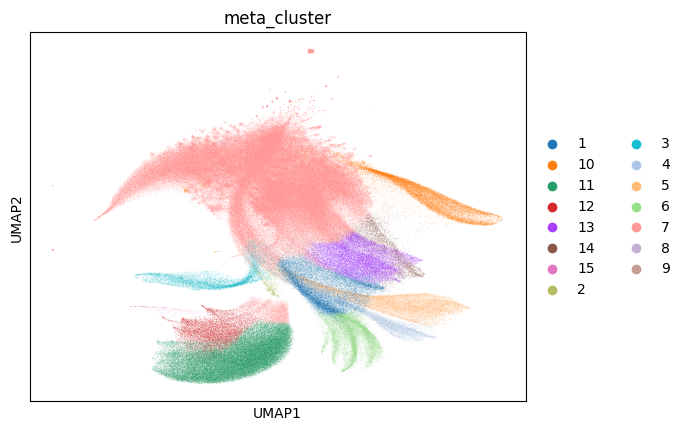

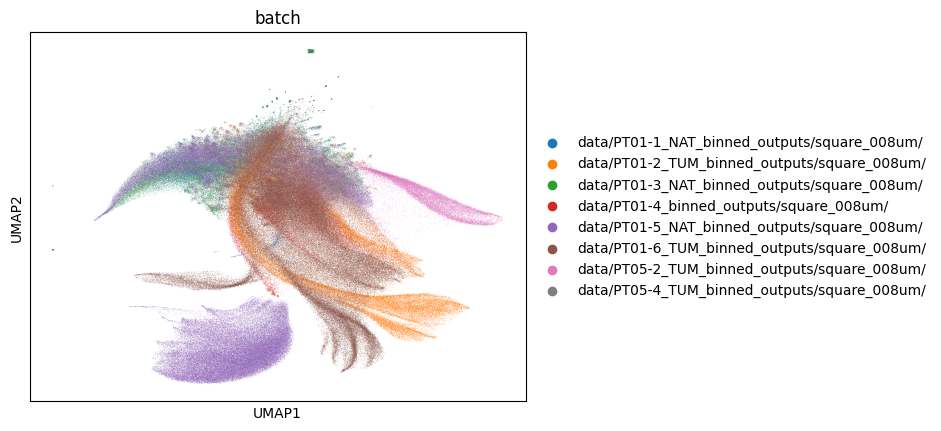

In [14]:
sc.pl.umap(adata, color = 'meta_cluster')
sc.pl.umap(adata, color = 'batch')

/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py

[<Axes: title={'center': '1 vs. rest'}, ylabel='score'>,
 <Axes: title={'center': '10 vs. rest'}>,
 <Axes: title={'center': '11 vs. rest'}>,
 <Axes: title={'center': '12 vs. rest'}>,
 <Axes: title={'center': '13 vs. rest'}, ylabel='score'>,
 <Axes: title={'center': '14 vs. rest'}>,
 <Axes: title={'center': '15 vs. rest'}>,
 <Axes: title={'center': '2 vs. rest'}>,
 <Axes: title={'center': '3 vs. rest'}, ylabel='score'>,
 <Axes: title={'center': '4 vs. rest'}>,
 <Axes: title={'center': '5 vs. rest'}>,
 <Axes: title={'center': '6 vs. rest'}>,
 <Axes: title={'center': '7 vs. rest'}, xlabel='ranking', ylabel='score'>,
 <Axes: title={'center': '8 vs. rest'}, xlabel='ranking'>,
 <Axes: title={'center': '9 vs. rest'}, xlabel='ranking'>]

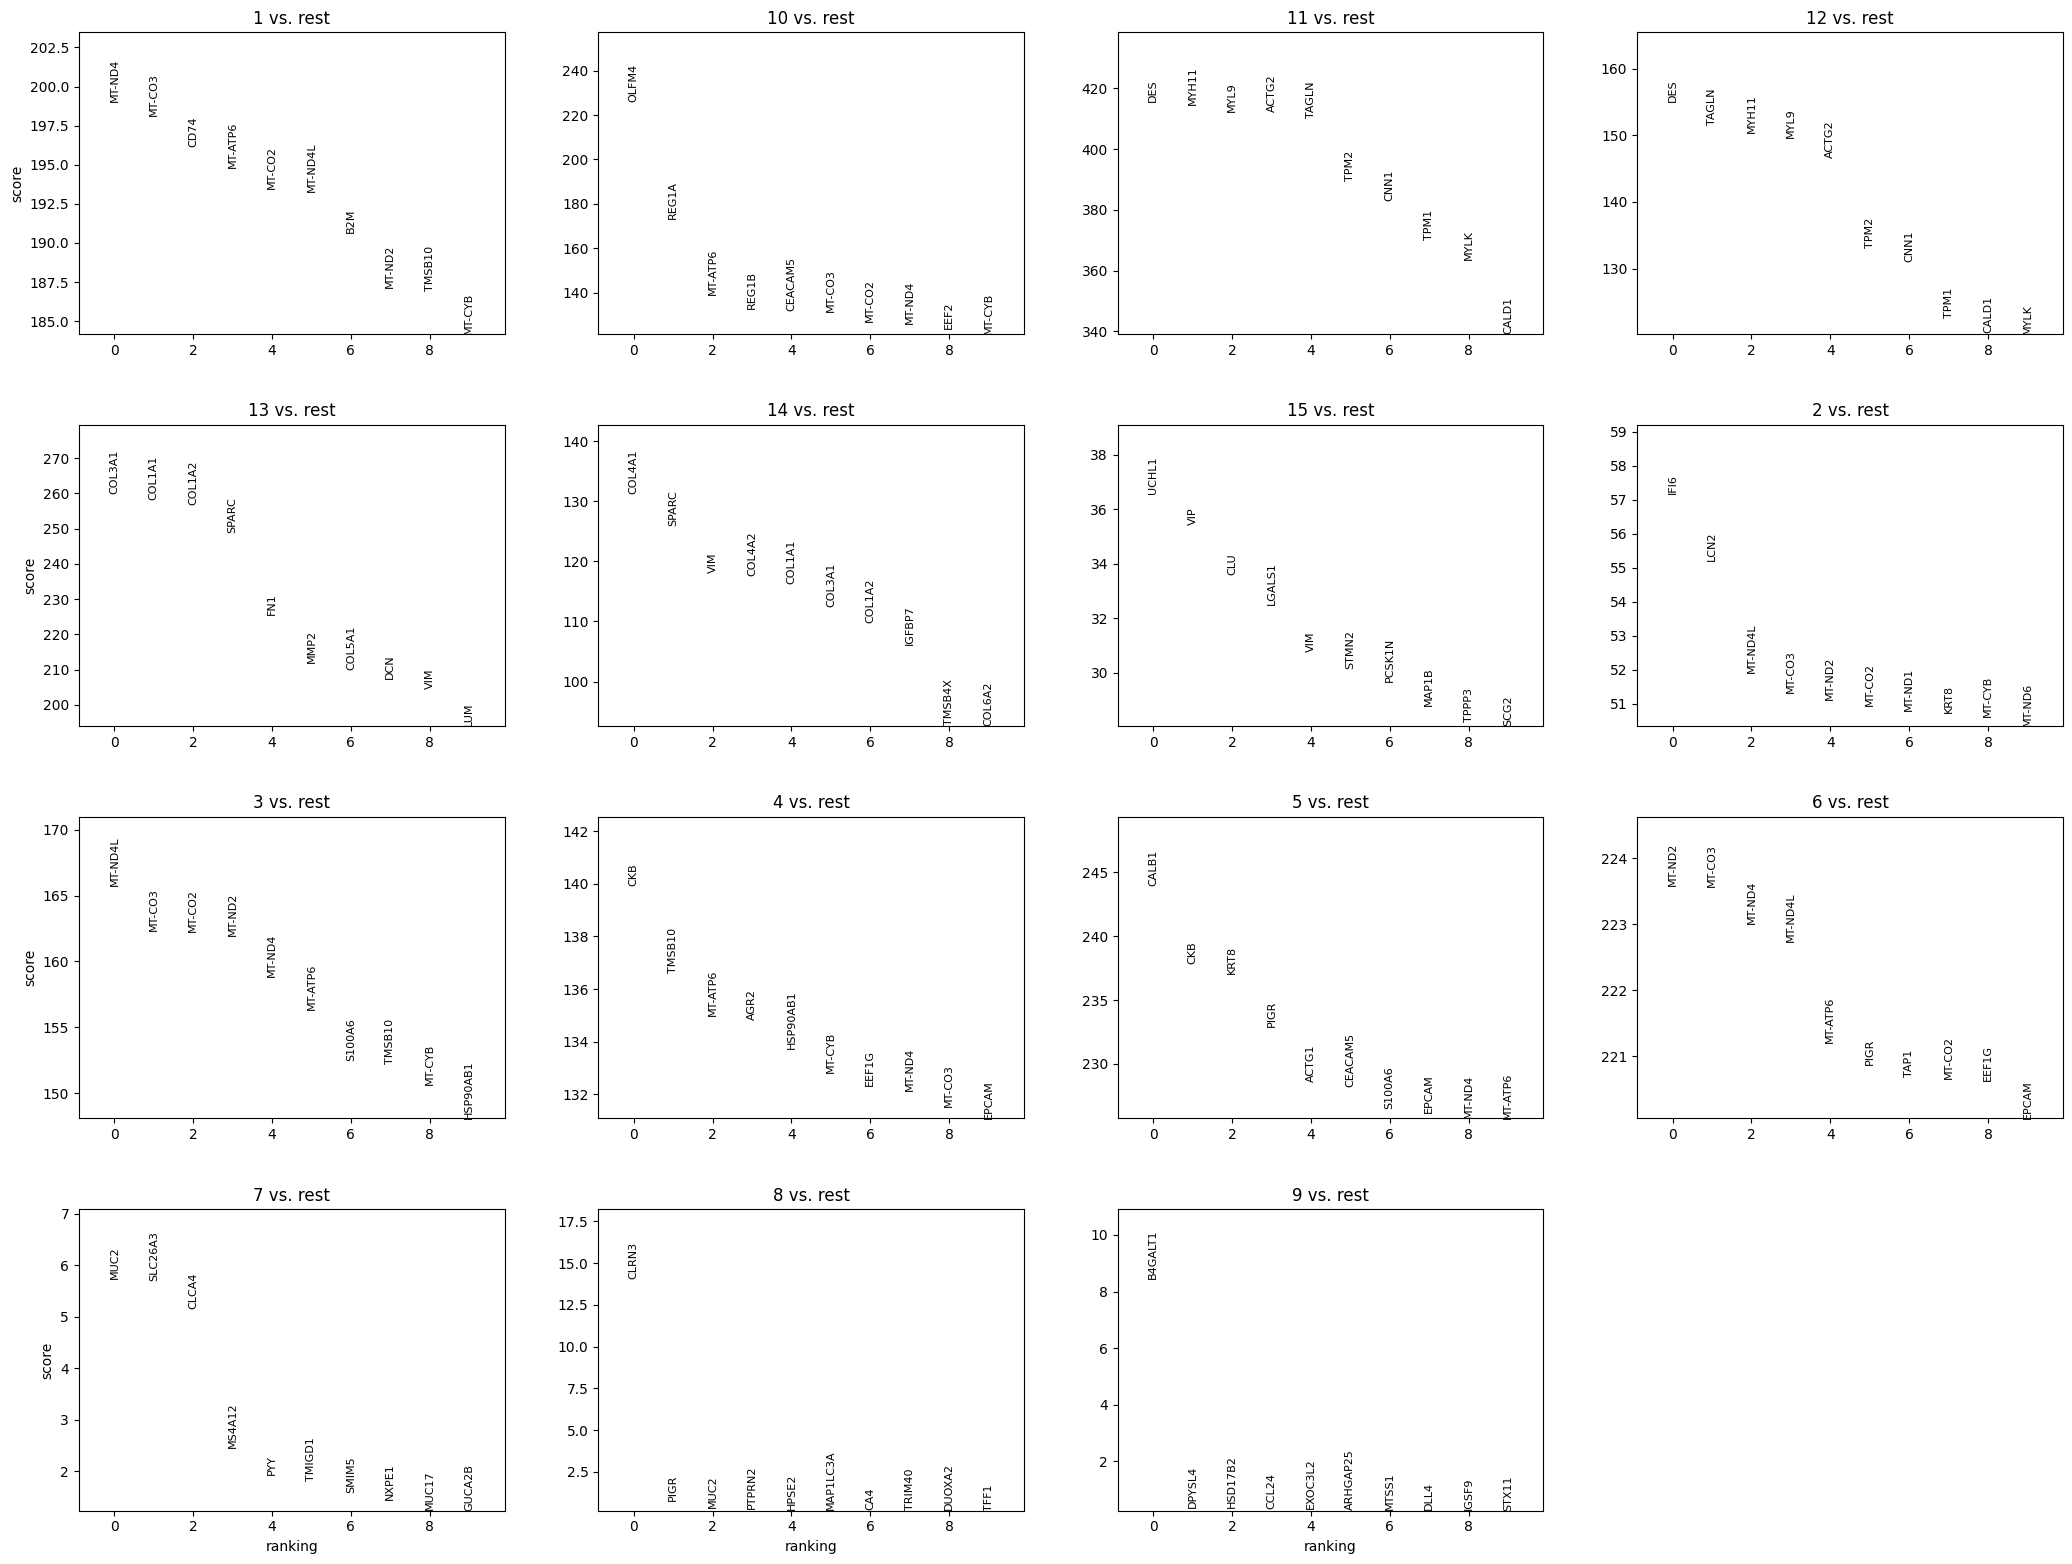

In [4]:
sc.tl.rank_genes_groups(adata, 'meta_cluster', method='wilcoxon', use_raw = False)
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False, show = False)

In [6]:
import pandas as pd
marker_df = sc.get.rank_genes_groups_df(adata, group=None)
print(marker_df.groupby('group').head(3))

idx = adata.obs['meta_cluster'].value_counts() > 1000
adata_subset = adata[adata.obs['meta_cluster'].isin(idx[idx].index)].copy()
adata_subset.obs['meta_cluster'] = pd.Categorical(adata_subset.obs['meta_cluster'], categories = idx[idx].index.tolist())

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/2789446427.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(marker_df.groupby('group').head(3))


      group    names      scores  logfoldchanges          pvals      pvals_adj
0         1   MT-ND4  199.012848             NaN   0.000000e+00   0.000000e+00
1         1   MT-CO3  198.092743             NaN   0.000000e+00   0.000000e+00
2         1     CD74  196.141708             NaN   0.000000e+00   0.000000e+00
5000     10    OLFM4  225.904800             NaN   0.000000e+00   0.000000e+00
5001     10    REG1A  173.264755             NaN   0.000000e+00   0.000000e+00
5002     10  MT-ATP6  138.859131             NaN   0.000000e+00   0.000000e+00
10000    11      DES  415.518585             NaN   0.000000e+00   0.000000e+00
10001    11    MYH11  414.444183             NaN   0.000000e+00   0.000000e+00
10002    11     MYL9  412.232727             NaN   0.000000e+00   0.000000e+00
15000    12      DES  155.015854             NaN   0.000000e+00   0.000000e+00
15001    12    TAGLN  151.562256             NaN   0.000000e+00   0.000000e+00
15002    12    MYH11  150.316269             NaN   0

/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/3655957242.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_genes = sc.get.rank_genes_groups_df(adata, group=None).groupby('group').head(5)
/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/3655957242.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marker_dict = top_genes.groupby('group')['names'].apply(list).to_dict()


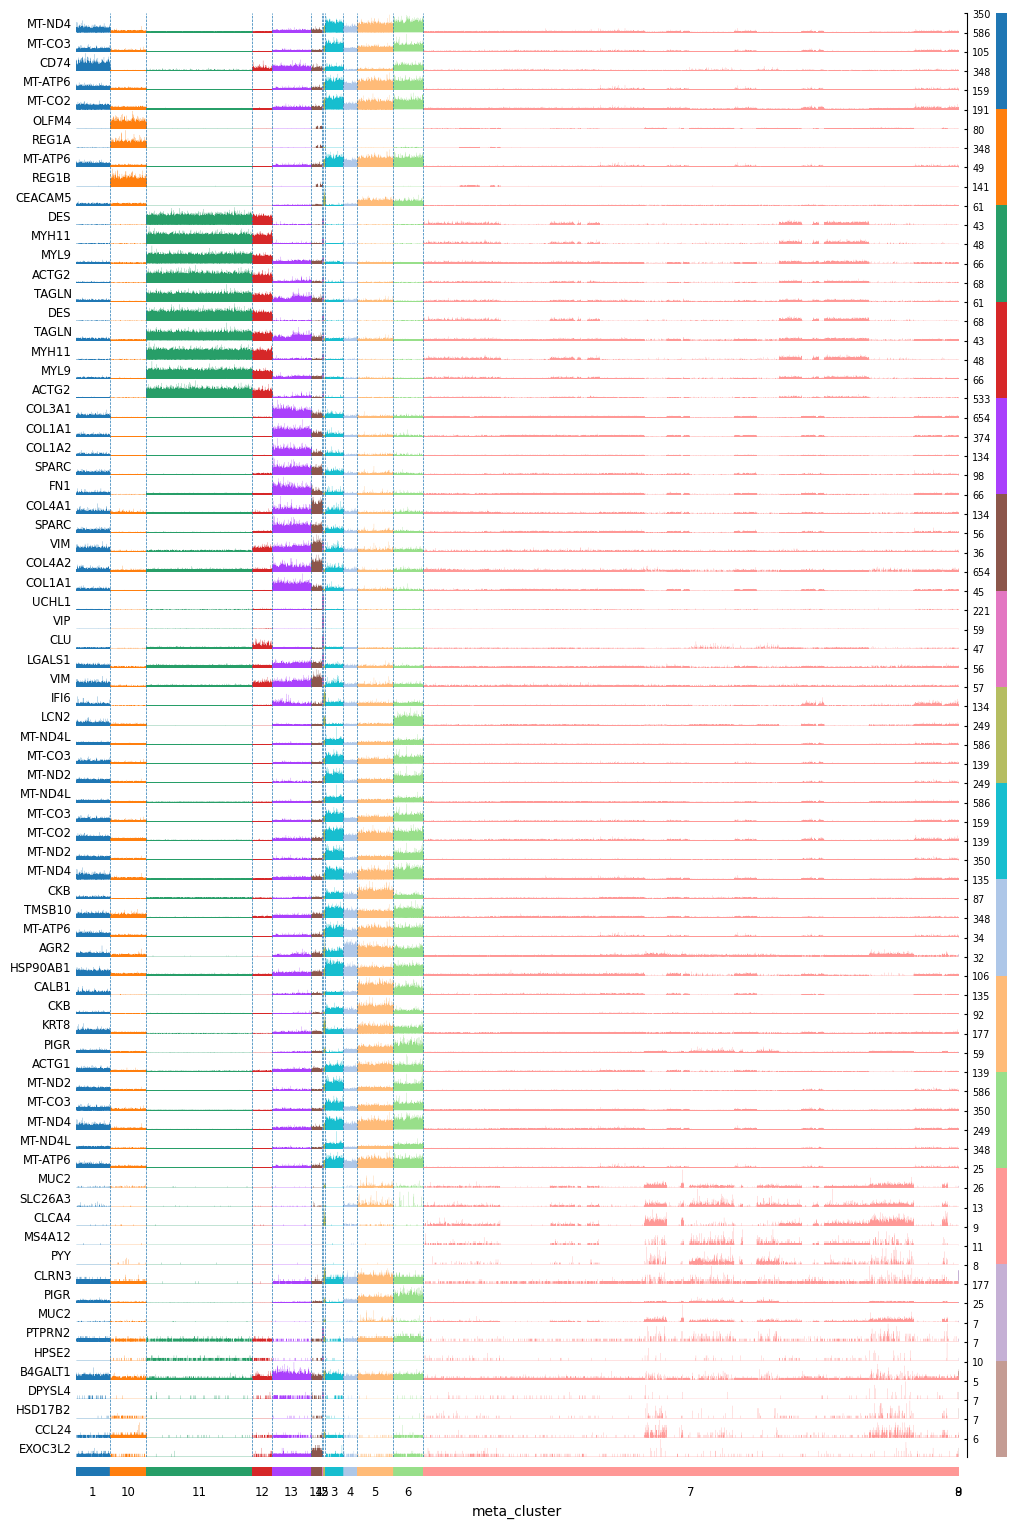

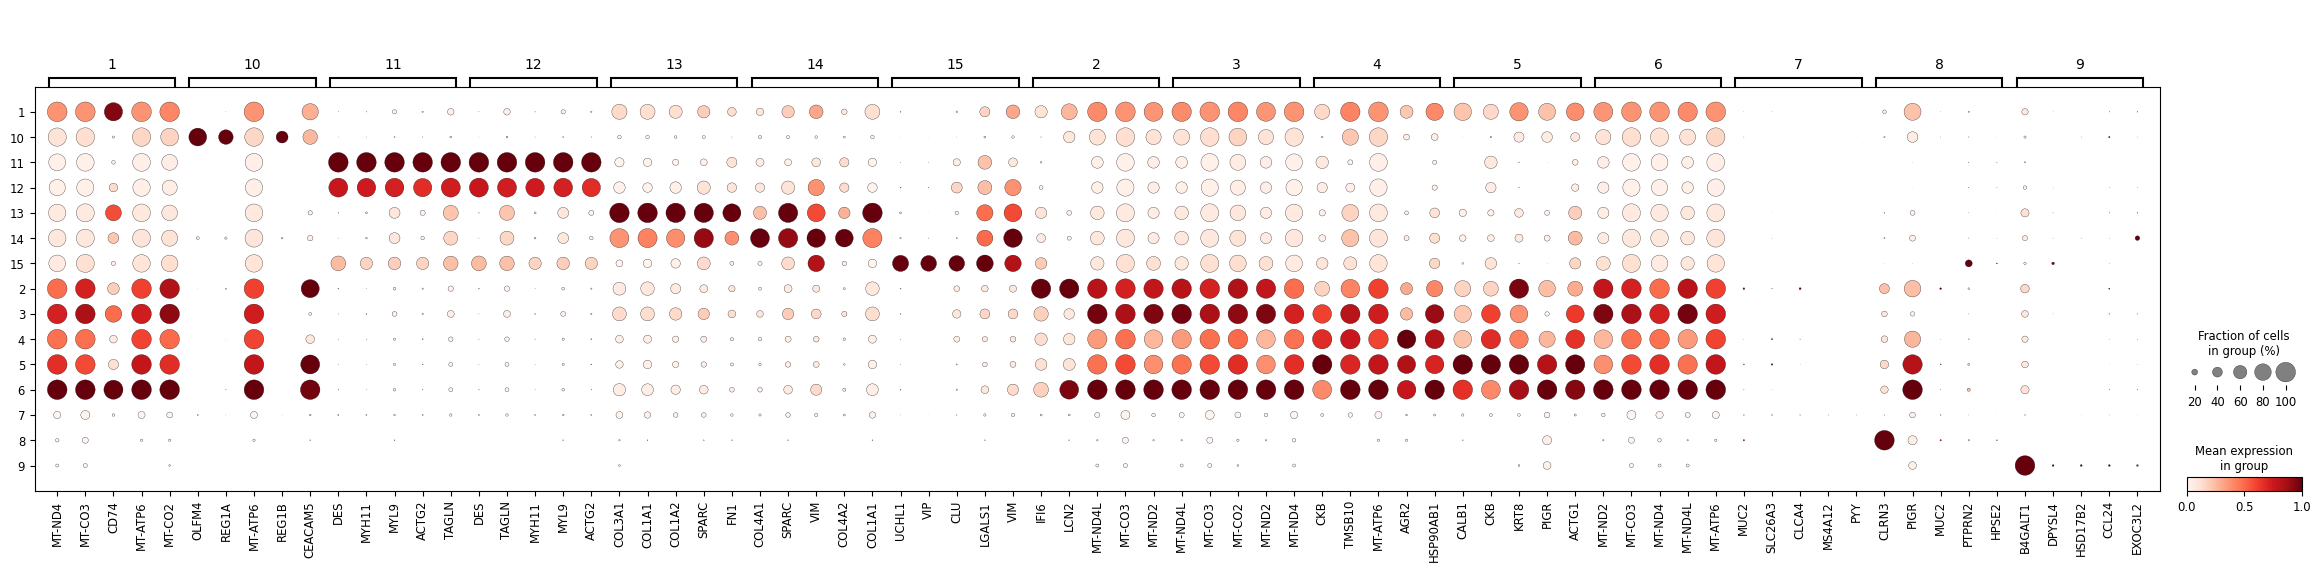

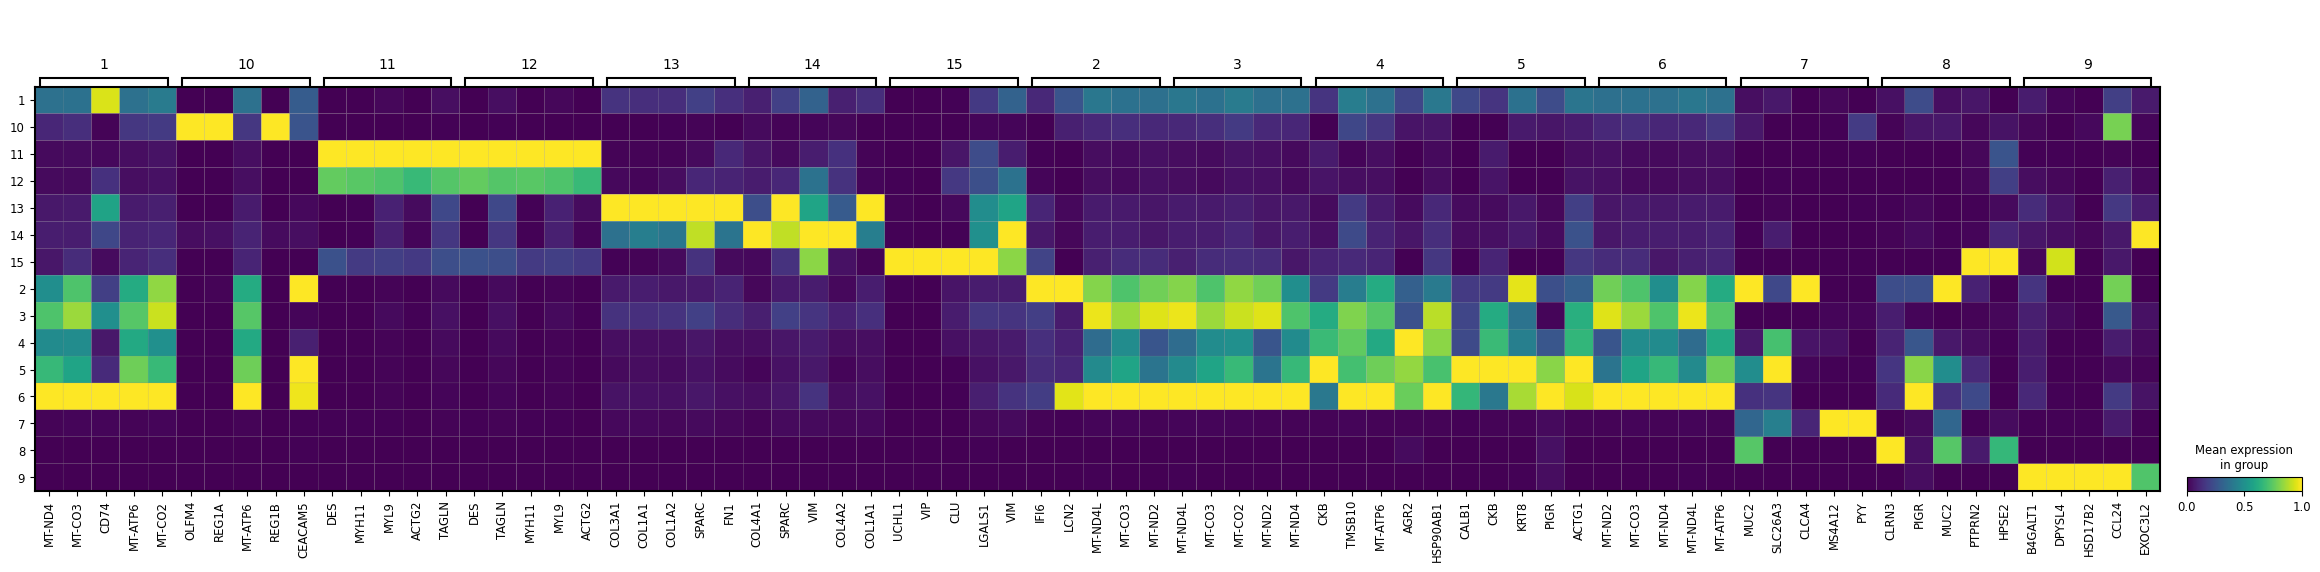

In [16]:
# Extract top 5 marker genes per cluster
top_genes = sc.get.rank_genes_groups_df(adata, group=None).groupby('group').head(5)
marker_dict = top_genes.groupby('group')['names'].apply(list).to_dict()

sc.pl.tracksplot(
    adata,
    var_names=marker_dict,
    groupby="meta_cluster",
    dendrogram=False,
    sort=True
)

sc.pl.dotplot(adata, var_names=marker_dict, groupby="meta_cluster", standard_scale='var')

sc.pl.matrixplot(adata, var_names=marker_dict, groupby="meta_cluster", standard_scale='var')

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/1239383280.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['leiden', 'meta_cluster'], spot_size = 5, title = batch)


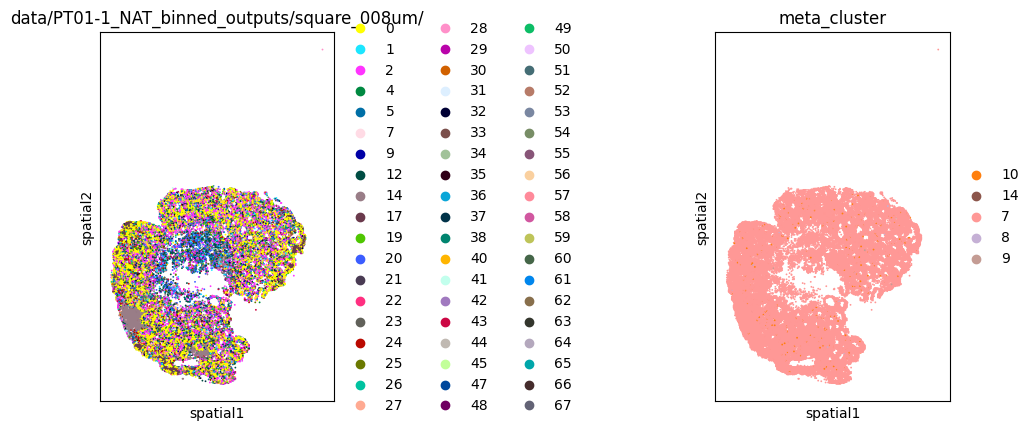

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/1239383280.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['leiden', 'meta_cluster'], spot_size = 5, title = batch)


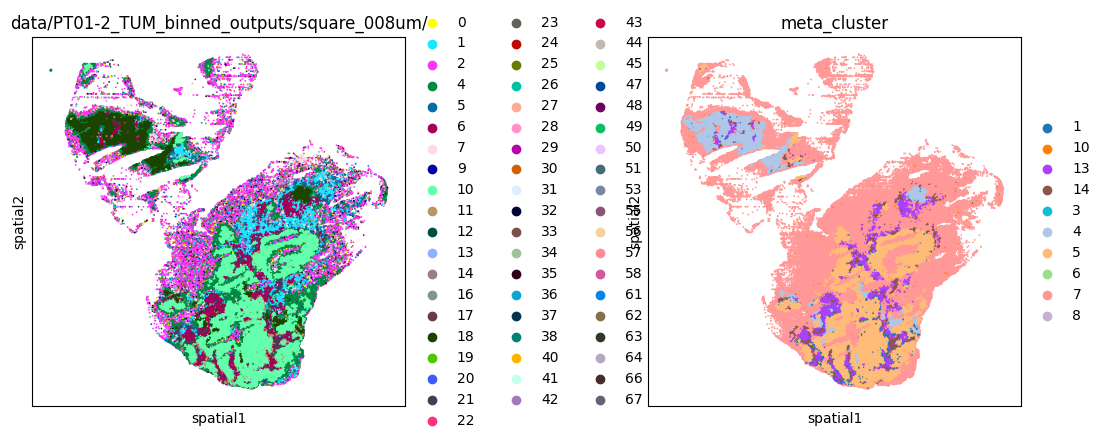

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/1239383280.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['leiden', 'meta_cluster'], spot_size = 5, title = batch)


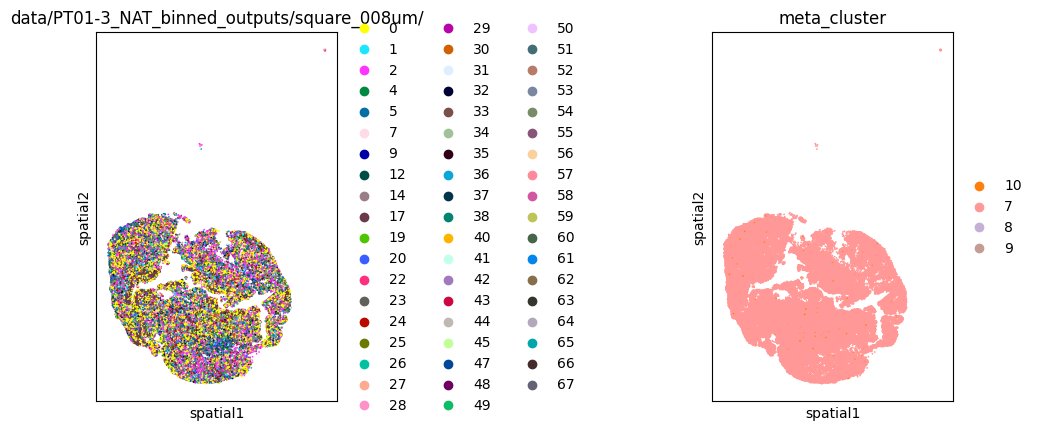

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/1239383280.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['leiden', 'meta_cluster'], spot_size = 5, title = batch)


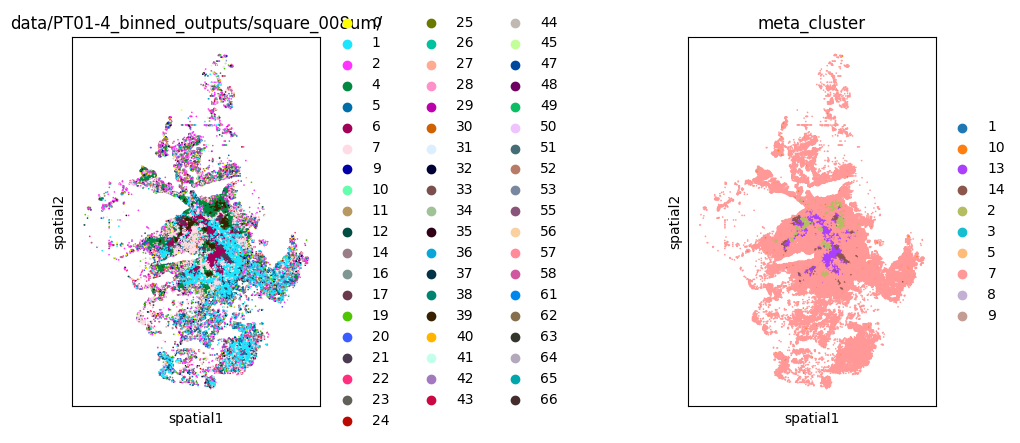

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/1239383280.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['leiden', 'meta_cluster'], spot_size = 5, title = batch)


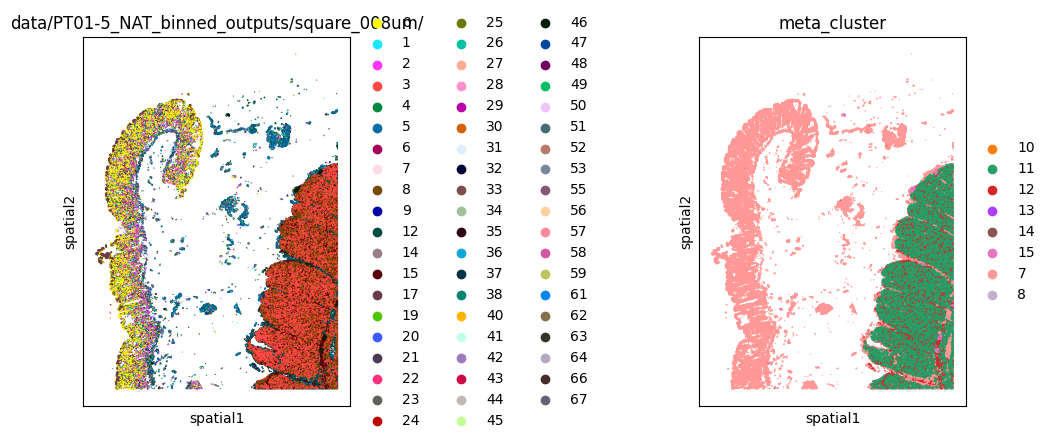

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/1239383280.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['leiden', 'meta_cluster'], spot_size = 5, title = batch)


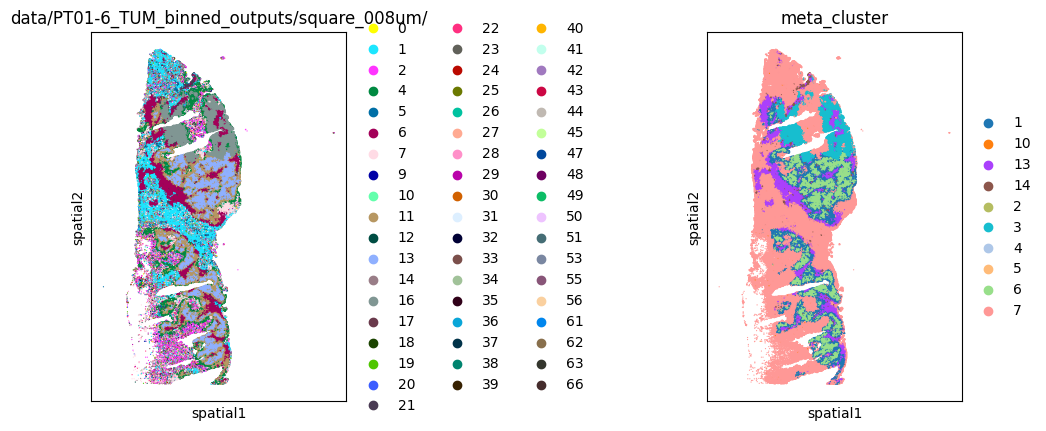

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/1239383280.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['leiden', 'meta_cluster'], spot_size = 5, title = batch)


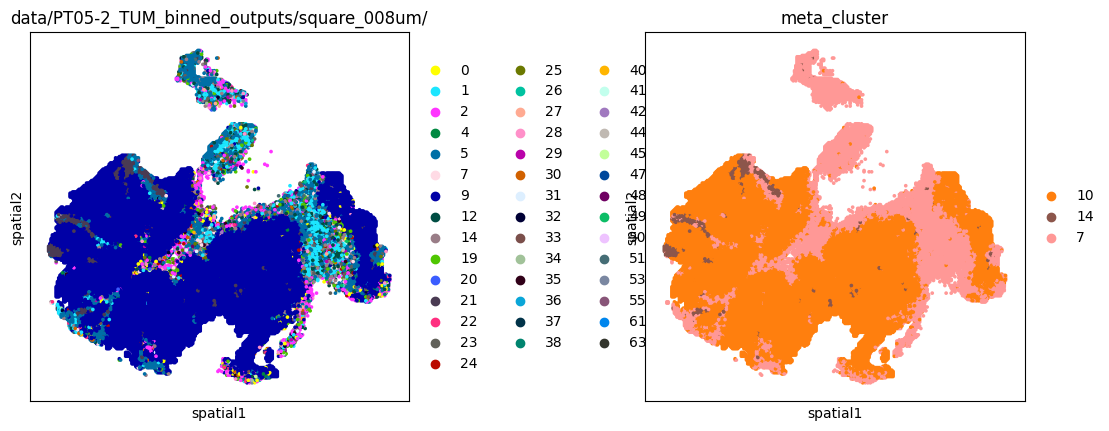

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16052/1239383280.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['leiden', 'meta_cluster'], spot_size = 5, title = batch)


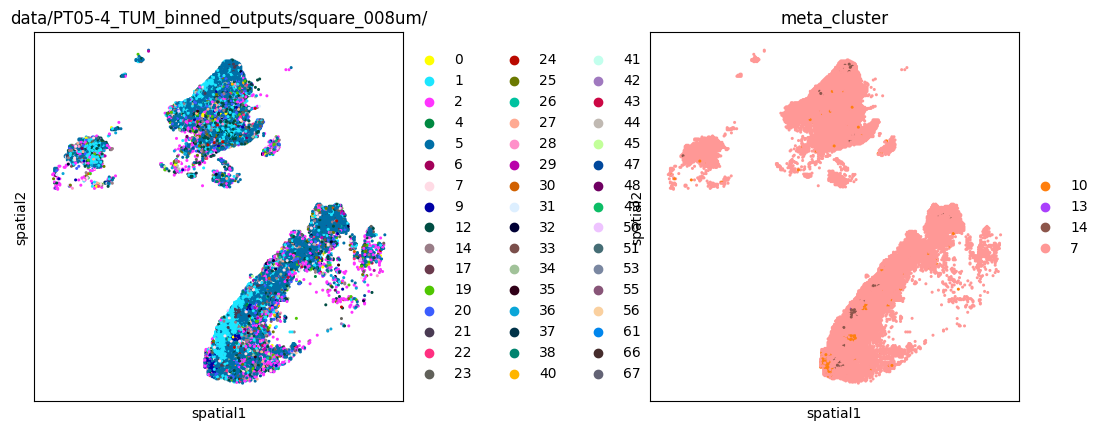

In [19]:
for batch in adata.obs['batch'].unique():
    a = adata[adata.obs['batch']==batch].copy()
    sc.pl.spatial(a, color = ['leiden', 'meta_cluster'], spot_size = 5, title = batch)